# Figure 9b: Westerly band width vs. carbon uptake

Scatter plot of the width of the Southern Hemisphere westerly wind band
against the annual-mean integrated carbon uptake south of 30S (in
Pg C/yr), with the line of best fit.

Russell, J.L., et al. (2018), Metrics for the evaluation of the Southern Ocean in coupled climate models and earth system models, *J. Geophysical Research - Oceans*, 123, 3120-3143, [doi:10.1002/2017JC013461](https://doi.org/10.1002/2017JC013461).

---

### About these notebooks

This notebook is one of a set reproducing the figures of Russell et al.
(2018), a suite of metrics for evaluating the Southern Ocean in coupled
climate and earth system models.

They are a Python translation of the NCL diagnostics distributed with
[ESMValTool](https://github.com/ESMValGroup/ESMValTool)
(`esmvaltool/diag_scripts/russell18jgr/`, driven by
`recipe_russell18jgr.yml`), rewritten so that each figure stands alone
and can be run interactively without going through a recipe.

Translated and maintained by **Romain Beucher**,
[ACCESS-NRI](https://www.access-nri.org.au).
Please contact <romain.beucher@anu.edu.au> with any questions.

## Scientific background

The carbon counterpart of Figure 9a: the width of the westerly wind band
against the total carbon taken up south of 30S.

The circulation that controls heat uptake also controls carbon uptake,
so a relationship here would suggest that improving the simulated winds
would improve the simulated carbon sink. Russell et al. (2018) caution
that the relationship is not exact and that the band width is only one
of several controls.

## Setup

This notebook is standalone: everything it needs is defined below.  It
requires `esmvalcore`, `iris`, `numpy`, `matplotlib` and `cartopy` -
the full ESMValTool is *not* needed.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## Helper functions

The helpers below are the parts of the original NCL diagnostic that are
worth keeping out of the way of the plotting code.  They are defined
here rather than imported so the notebook stands on its own.

In [2]:
# Constants used by the original NCL scripts
EARTH_RADIUS = 6.37e06   # m
DEG2RAD = 0.0174533


_COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]
_DASHES = ["-", "--", "-.", ":"]
_MARKERS = ["o", "s", "D", "^", "v", "P", "X", "*"]


def style_for(index):
    """Line and marker style for the index-th dataset."""
    return {
        "color": _COLORS[index % len(_COLORS)],
        "dash": _DASHES[index % len(_DASHES)],
        "thick": 1.5,
        "mark": _MARKERS[index % len(_MARKERS)],
    }


def coord_1d_or_2d(cube, axis):
    """Latitude/longitude points, which may be 1D or 2D.

    ESMValTool preprocessed ocean files carry either 1D dimension
    coordinates (regular grids) or 2D auxiliary coordinates
    (curvilinear grids); this hides the difference.
    """
    return np.asarray(cube.coord(axis).points)


def has_regular_grid(cube):
    """True if the cube has 1D latitude and longitude coordinates."""
    return (cube.coord("latitude").ndim == 1
            and cube.coord("longitude").ndim == 1)


def lat_1d(cube):
    """A representative 1D latitude array (column 0 for 2D grids)."""
    lat = coord_1d_or_2d(cube, "latitude")
    return lat[:, 0] if lat.ndim == 2 else lat


def lon_1d(cube):
    """A representative 1D longitude array (row 0 for 2D grids)."""
    lon = coord_1d_or_2d(cube, "longitude")
    return lon[0, :] if lon.ndim == 2 else lon


def closest_index(value, array):
    """Index of the array element closest to value (NCL closest_val)."""
    array = np.asarray(array, dtype=float)
    return int(np.nanargmin(np.abs(array - value)))


def zonal_mean(data):
    """Mean over the last (longitude/i) axis, honouring the mask."""
    return np.ma.mean(np.ma.masked_invalid(data), axis=-1)


def ncl_cell_area(lat, lon, shape):
    """Cell areas of a regular lat-lon grid, as computed in NCL.

    Replicates the manual areacello calculation of the NCL scripts:
    a constant dlat/dlon taken from grid points 19 and 20, then
    area = dx * dy with dx = R cos(lat) dlon and dy = R dlat.
    """
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    dlat = abs(lat[20] - lat[19])
    dlon = abs(lon[20] - lon[19])
    dx = dlon * EARTH_RADIUS * DEG2RAD * np.cos(lat * DEG2RAD)
    dy = dlat * EARTH_RADIUS * DEG2RAD
    return np.broadcast_to((dx * dy)[:, np.newaxis], shape)


def westerly_band_width(tauu_zonal, lat):
    """Latitudinal width of the SH westerly wind band.

    Starting from the latitude closest to 50S, find the first zero
    crossing of the zonal-mean zonal wind stress equatorward (+ to -)
    and the last zero crossing poleward of 50S (- to +), both linearly
    interpolated.
    """
    tauu = np.ma.masked_invalid(np.asarray(tauu_zonal, dtype=float))
    lat = np.asarray(lat, dtype=float)
    a1, a2 = closest_index(-50.0, lat), closest_index(-75.0, lat)

    upper = lower = None
    for i in range(a1, len(lat) // 2):
        if tauu[i] >= 0 and tauu[i + 1] < 0:
            upper = lat[i] - ((lat[i] - lat[i + 1]) * tauu[i]
                              / (tauu[i] - tauu[i + 1]))
            break
    for i in range(a2, a1 + 1):
        if tauu[i] < 0 and tauu[i + 1] >= 0:
            lower = lat[i] - ((lat[i] - lat[i + 1]) * tauu[i]
                              / (tauu[i] - tauu[i + 1]))
    if upper is None or lower is None:
        raise ValueError("No zero crossings of the wind stress near 50S")
    return float(upper - lower)


def southern_ocean_flux_sum(flux2d, area, lat, factor):
    """Integrated flux south of 30S: sum(flux * area) * factor.

    The flux per cell is summed along longitude and then from the pole
    up to the latitude row closest to 30S (ESMValTool preprocessed
    CMIP data is ordered south to north).
    """
    per_cell = (np.ma.masked_invalid(np.asarray(flux2d, dtype=float))
                * np.ma.masked_invalid(np.asarray(area, dtype=float))
                * factor)
    return float(per_cell.sum(axis=-1)[: closest_index(-30.0, lat) + 1].sum())

## Dask cluster

Start a local cluster so the preprocessor can work in parallel.  On
Gadi, size this to the resources of your ARE session / PBS job.

In [3]:
from dask.distributed import Client

client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35613 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/35613/status,
Dashboard: /proxy/35613/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40543,Workers: 0
Dashboard: /proxy/35613/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40079,Total threads: 2
Dashboard: /proxy/33843/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:33725,


## Datasets

Datasets are declared directly with `esmvalcore.dataset.Dataset`, so
this notebook does not need a recipe.  A small subset of the models of
the paper is used to keep the notebook quick; add entries to the
dictionary below to include more.

On Gadi the CMIP5 data comes from the `al33` and `rr3` projects - make
sure both are in the `storage` flags of your session.

In [4]:
from esmvalcore.dataset import Dataset

tauuo_datasets = {
    "CNRM-CM5": Dataset(
        short_name="tauuo",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="CNRM-CM5",
        timerange="19860101/20051231",
    ),
    "GFDL-ESM2G": Dataset(
        short_name="tauuo",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="GFDL-ESM2G",
        timerange="19860101/20051231",
    ),
    "MIROC-ESM": Dataset(
        short_name="tauuo",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="MIROC-ESM",
        timerange="19860101/20051231",
    ),
    "MRI-ESM1": Dataset(
        short_name="tauuo",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="MRI-ESM1",
        timerange="19860101/20051231",
    ),
}

fgco2_datasets = {
    "CNRM-CM5": Dataset(
        short_name="fgco2",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="CNRM-CM5",
        timerange="19860101/20051231",
    ),
    "GFDL-ESM2G": Dataset(
        short_name="fgco2",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="GFDL-ESM2G",
        timerange="19860101/20051231",
    ),
    "MIROC-ESM": Dataset(
        short_name="fgco2",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="MIROC-ESM",
        timerange="19860101/20051231",
    ),
    "MRI-ESM1": Dataset(
        short_name="fgco2",
        project="CMIP5",
        mip="Omon",
        exp="historical",
        ensemble="r1i1p1",
        dataset="MRI-ESM1",
        timerange="19860101/20051231",
    ),
}

areacello_datasets = {
    "CNRM-CM5": Dataset(
        short_name="areacello",
        project="CMIP5",
        mip="fx",
        exp="historical",
        ensemble="r0i0p0",
        dataset="CNRM-CM5",
        timerange="19860101/20051231",
    ),
    "GFDL-ESM2G": Dataset(
        short_name="areacello",
        project="CMIP5",
        mip="fx",
        exp="historical",
        ensemble="r0i0p0",
        dataset="GFDL-ESM2G",
        timerange="19860101/20051231",
    ),
    "MIROC-ESM": Dataset(
        short_name="areacello",
        project="CMIP5",
        mip="fx",
        exp="historical",
        ensemble="r0i0p0",
        dataset="MIROC-ESM",
        timerange="19860101/20051231",
    ),
    "MRI-ESM1": Dataset(
        short_name="areacello",
        project="CMIP5",
        mip="fx",
        exp="historical",
        ensemble="r0i0p0",
        dataset="MRI-ESM1",
        timerange="19860101/20051231",
    ),
}

<details>
<summary>Using ACCESS (CMIP6) models instead</summary>

The figures of the paper are CMIP5.  To evaluate an ACCESS model,
switch `project` to `CMIP6`, use a CMIP6 ensemble/grid label and the
CMIP6 variable names, e.g.

```python
Dataset(
    short_name="thetao", project="CMIP6", mip="Omon", exp="historical",
    ensemble="r1i1p1f1", grid="gn", dataset="ACCESS-ESM1-5",
    timerange="19860101/20051231",
)
```

Note the CMIP6 renaming of some variables (`sic` -> `siconc`,
`tauuo` is not always published) and that `volcello` and `areacello`
moved from `fx` to `Ofx`.
</details>

## Preprocessing

`climate_statistics` takes the full-period time mean, as the
`preprocessor_time` preprocessor of the recipe does.

In [5]:
from esmvalcore.preprocessor import climate_statistics


def preprocess(cube):
    """Full-period time mean (preprocessor_time)."""
    return climate_statistics(cube, operator="mean", period="full")


tauuo_cubes = {name: preprocess(dataset.load()) for name, dataset in tauuo_datasets.items()}
fgco2_cubes = {name: preprocess(dataset.load()) for name, dataset in fgco2_datasets.items()}
areacello_cubes = {name: dataset.load() for name, dataset in areacello_datasets.items()}

tauuo_cubes

 tauuo: attribute positive not present
loaded from file 
 tauuo: attribute positive not present
loaded from file 
 tauuo: attribute positive not present
loaded from file 
 tauuo: attribute positive not present
loaded from file 
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/iris/fileformats/_nc_load_rules/helpers.py:498: UnknownCellMethodWarning: NetCDF variable 'fgco2' contains unknown cell method 'where'
  warnings.warn(msg, category=UnknownCellMethodWarning)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/iris/fileformats/_nc_load_rules/helpers.py:498: UnknownCellMethodWarning: NetCDF variable 'fgco2' contains unknown cell method 'where'
  warnings.warn(msg, category=UnknownCellMethodWarning)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.09/lib/python3.12/site-packages/iris/fileformats/_nc_load_rules/helpers.py:498: UnknownCellMethodWarning: NetCDF variable 'fgco2' contains unknown cell method 'where'


{'CNRM-CM5': <iris 'Cube' of surface_downward_x_stress / (N m-2) (cell index along second dimension: 292; cell index along first dimension: 362)>,
 'GFDL-ESM2G': <iris 'Cube' of surface_downward_x_stress / (N m-2) (grid_latitude: 210; grid_longitude: 360)>,
 'MIROC-ESM': <iris 'Cube' of surface_downward_x_stress / (N m-2) (latitude: 192; longitude: 256)>,
 'MRI-ESM1': <iris 'Cube' of surface_downward_x_stress / (N m-2) (grid_latitude: 368; grid_longitude: 360)>}

## Diagnostic

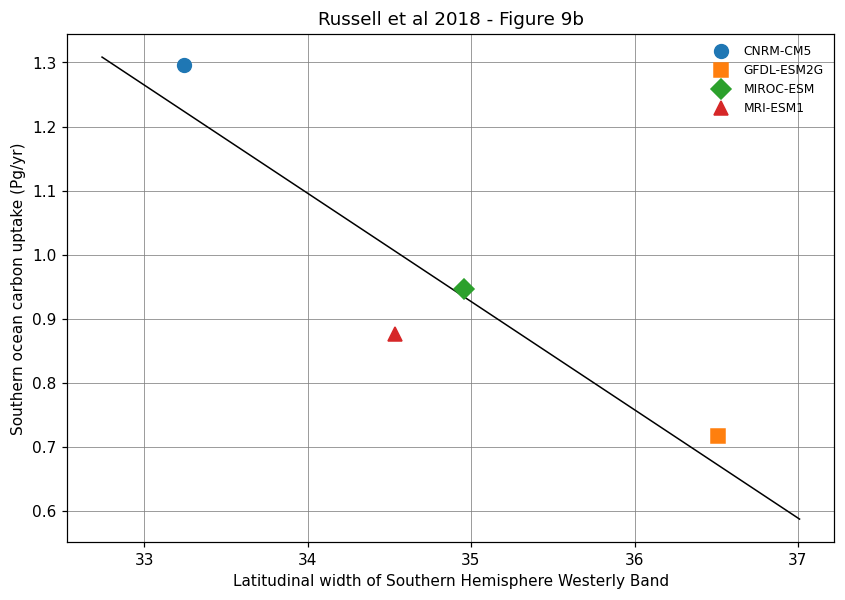

slope = -0.169, intercept = 6.841


In [6]:
CARBON_FACTOR = 0.000031536   # kg s-1 -> Pg yr-1
HEAT_FACTOR = 1.0e-15         # W -> PW

names, xvals, yvals = [], [], []

for name in tauuo_cubes:
    # width of the westerly band from the zonal-mean wind stress
    tauu = tauuo_cubes[name]
    lat = coord_1d_or_2d(tauu, "latitude")
    if lat.ndim == 2:
        lat = np.mean(lat, axis=1)
    xvals.append(westerly_band_width(zonal_mean(tauu.data), lat))

    # integrated carbon uptake south of 30S
    fgco2 = fgco2_cubes[name]
    if has_regular_grid(fgco2):
        area = ncl_cell_area(lat_1d(fgco2), lon_1d(fgco2), fgco2.shape)
    else:
        area = np.ma.masked_invalid(areacello_cubes[name].data)
    yvals.append(southern_ocean_flux_sum(
        fgco2.data, area, lat_1d(fgco2), CARBON_FACTOR))
    names.append(name)

xvals, yvals = np.array(xvals), np.array(yvals)

fig, ax = plt.subplots(figsize=(9, 6))

# line of best fit
slope, intercept = np.polyfit(xvals, yvals, 1)
xline = np.linspace(xvals.min() - 0.5, xvals.max() + 0.5, 50)
ax.plot(xline, intercept + slope * xline, color="black", linewidth=1)

for i, (x, y, name) in enumerate(zip(xvals, yvals, names)):
    style = style_for(i)
    ax.plot(x, y, linestyle="none", marker=style["mark"],
            color=style["color"], markersize=9, label=name)

ax.grid(color="grey", linewidth=0.5)
ax.set_xlabel("Latitudinal width of Southern Hemisphere Westerly Band")
ax.set_ylabel("Southern ocean carbon uptake (Pg/yr)")
ax.set_title("Russell et al 2018 - Figure 9b")
ax.legend(fontsize=8, frameon=False)
plt.show()

print(f"slope = {slope:.3f}, intercept = {intercept:.3f}")

**Figure 9b: Westerly band width vs. carbon uptake:** Width of the Southern Hemisphere westerly wind band against the annual-mean
integrated carbon uptake south of 30S, with the line of best fit.